**DURING DIFFERENT TRAIN TEST SPLIT CASES, THE METRICS VALUE WILL BE DIFFERENT FOR EACH CASE.SO WE CAN TAKE THEIR MEAN AND CONSIDERED THIS THE ACTUAL VALUE.**

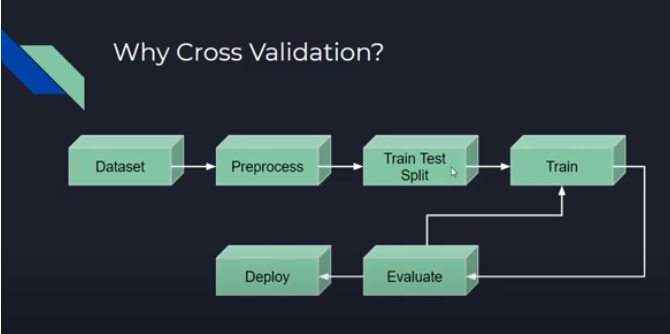

In [66]:
import numpy as np
import pandas as pd

In [67]:
df=pd.read_csv("placement (for regression).csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [68]:
x = df.iloc[0:50,0:1]
y = df.iloc[0:50,-1]

In [69]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [70]:
from xgboost import XGBRegressor
xg = XGBRegressor()
xg.fit(x,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

In [71]:
from sklearn.metrics import r2_score
y_pred = xg.predict(x_test)
print("R^2 score for XG",r2_score(y_test,y_pred))

R^2 score for XG 0.9711400139882875




---



---



---



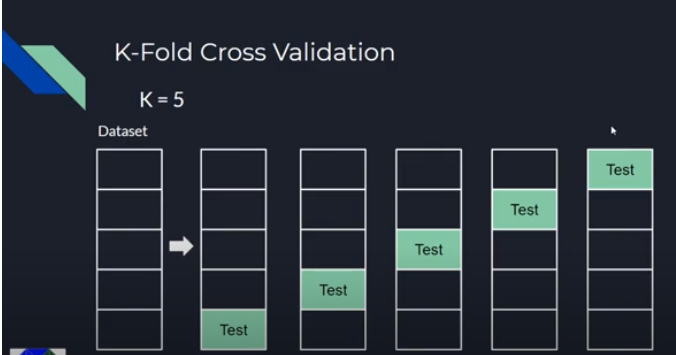

In [72]:
from sklearn.model_selection import KFold

In [73]:
kf = KFold(n_splits=10)
for train,test in kf.split(x):
  print(test,train)

[0 1 2 3 4] [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
[5 6 7 8 9] [ 0  1  2  3  4 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
[10 11 12 13 14] [ 0  1  2  3  4  5  6  7  8  9 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
[15 16 17 18 19] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
[20 21 22 23 24] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
[25 26 27 28 29] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
[30 31 32 33 34] [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20

- **THER IS STILL ONE PROBLEM THAT WHAT IF THHERE IS UNEQUAL PROPORTIONS ARE PRESENT IN OUR TEST SET!**

- **THE ANSWERE IS STRATIFIED SAMPLING WHICH IS BUILTIN IN CROSS VALL SCORE FUNCTION OF SKLAERN**

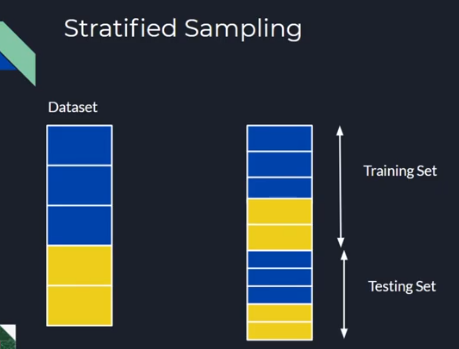

In [74]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xg,x,y,cv=10,scoring="r2")
scores

array([ 0.50953402,  0.52827532,  0.20997464, -0.10699112, -0.29568653,
        0.80684934,  0.39013877,  0.85164461,  0.59812285,  0.35622629])

In [75]:
scores.mean()

0.3848088193363501

**IMPORTANT THING TO CONSIDER HERE IS THE VARIANCE IN THE ACCURACY THAT WHY CROSS VALIDATION IS IMORTANT**

In [78]:
from sklearn.metrics import SCORERS
list(SCORERS.keys())


['explained_variance',
 'r2',
 'max_error',
 'matthews_corrcoef',
 'neg_median_absolute_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_root_mean_squared_error',
 'neg_mean_poisson_deviance',
 'neg_mean_gamma_deviance',
 'accuracy',
 'top_k_accuracy',
 'roc_auc',
 'roc_auc_ovr',
 'roc_auc_ovo',
 'roc_auc_ovr_weighted',
 'roc_auc_ovo_weighted',
 'balanced_accuracy',
 'average_precision',
 'neg_log_loss',
 'neg_brier_score',
 'positive_likelihood_ratio',
 'neg_negative_likelihood_ratio',
 'adjusted_rand_score',
 'rand_score',
 'homogeneity_score',
 'completeness_score',
 'v_measure_score',
 'mutual_info_score',
 'adjusted_mutual_info_score',
 'normalized_mutual_info_score',
 'fowlkes_mallows_score',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'recall',
 'recall_macro',
 'recall_micro',
 'recall_samples',
 'recall_weighted',
 'f1',
 'f1_macro',